In [1]:
The goal of this project is to predict car prices based on:
- Manufacturing Year
- Engine Size
- Fuel Type
- Car Brand (Make)
- Car Model

## Model Used
XGBoost Regressor

SyntaxError: invalid syntax (2135806960.py, line 4)

In [2]:

# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

In [8]:
##  Load Dataset
df = pd.read_csv("cars_2010_2020.csv")

df.head(10)


,Make,Model,Year,Engine Size (L),Fuel Type,Price (USD)
0,Volkswagen,Jetta,2010,4.2,Petrol,54073.09
1,Honda,Pilot,2017,4.2,Hybrid,44924.91
2,Nissan,Murano,2011,4.2,Hybrid,76963.44
3,Toyota,RAV4,2010,2.4,Petrol,30871.25
4,Nissan,Altima,2010,3.6,Petrol,72037.65
5,Ford,Focus,2011,2.6,Petrol,64616.84
6,Ford,Explorer,2016,2.0,Petrol,39159.35
7,BMW,7 Series,2018,4.0,Diesel,21455.06
8,Hyundai,Kona,2017,2.0,Electric,44998.91
9,Chevrolet,Impala,2016,1.6,Petrol,59598.11


In [9]:
##  Data Cleaning & Feature Engineering
df['Engine Size (L)'] = df['Engine Size (L)'].astype(float)
df['Year'] = df['Year'].astype(int)

# Create a new feature
df['Car Age'] = 2024 - df['Year']

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Make             10000 non-null  object 
 1   Model            10000 non-null  object 
 2   Year             10000 non-null  int64  
 3   Engine Size (L)  10000 non-null  float64
 4   Fuel Type        10000 non-null  object 
 5   Price (USD)      10000 non-null  float64
 6   Car Age          10000 non-null  int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 547.0+ KB


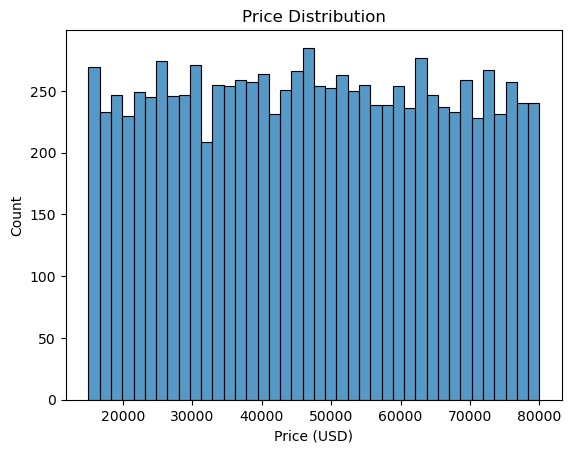

In [10]:
##  Exploratory Data Analysis (EDA)
# Price distribution
plt.figure()
sns.histplot(df['Price (USD)'], bins=40)
plt.title("Price Distribution")
plt.show()

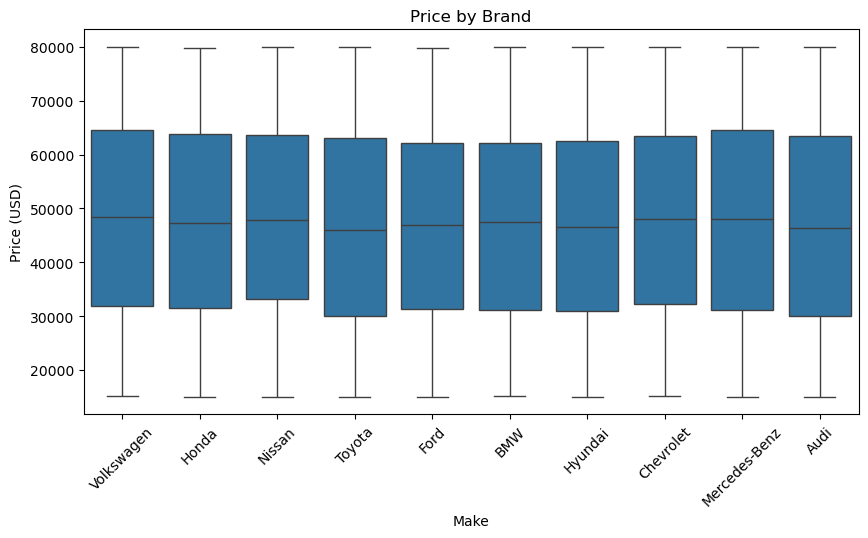

In [11]:
# Price by brand
plt.figure(figsize=(10,5))
sns.boxplot(x='Make', y='Price (USD)', data=df)
plt.xticks(rotation=45)
plt.title("Price by Brand")
plt.show()

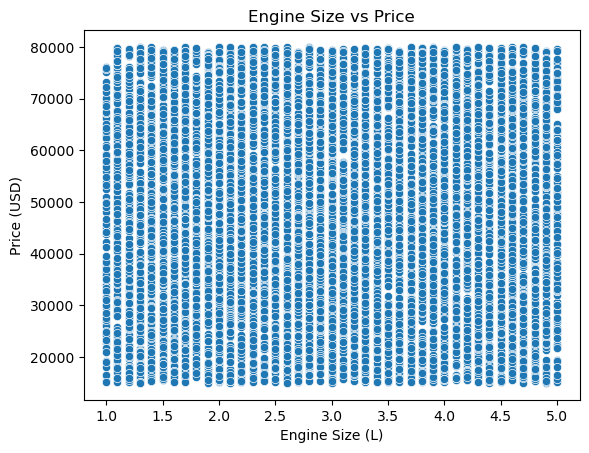

In [12]:
# Engine size vs price
plt.figure()
sns.scatterplot(x='Engine Size (L)', y='Price (USD)', data=df)
plt.title("Engine Size vs Price")
plt.show()

In [13]:
##  Feature Selection & Encoding
X = df[['Car Age', 'Engine Size (L)', 'Fuel Type', 'Make', 'Model']]
y = df['Price (USD)']

# One-hot encoding
X = pd.get_dummies(X, columns=['Fuel Type', 'Make', 'Model'], drop_first=True)

In [15]:
##  Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
##  Model Training
model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [17]:
##  Model Evaluation 
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 16634.248419960935
R2 Score: -0.09438052917626893


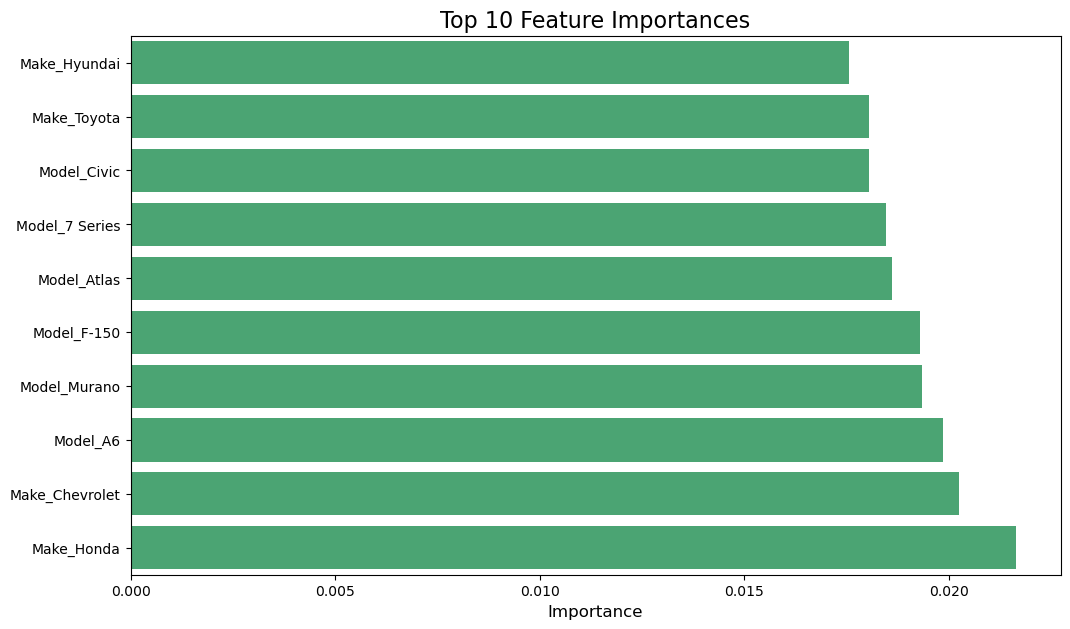

In [39]:
##  Feature Importance


feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=True)

top_feats = feat_importances[-10:]

plt.figure(figsize=(12,7))
sns.barplot(
    x=top_feats.values, 
    y=top_feats.index, 
    color="mediumseagreen"  
)

plt.title("Top 10 Feature Importances", fontsize=16)
plt.xlabel("Importance", fontsize=12)
plt.ylabel("")
plt.show()

In [30]:
##  Prediction Function
def predict_car_price(year, engine, fuel, make, model_name):
    car_age = 2024 - year

    new_data = pd.DataFrame([{
        'Car Age': car_age,
        'Engine Size (L)': engine,
        'Fuel Type': fuel,
        'Make': make,
        'Model': model_name
    }])

    new_data = pd.get_dummies(new_data).reindex(columns=X.columns, fill_value=0)

    return model.predict(new_data)[0]

In [31]:
price = predict_car_price(2020, 2.0, "Petrol", "Toyota", "Camry")

print(f"🚗 Predicted Price: ${price:,.2f}")

🚗 Predicted Price: $46,257.39
